In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# Temperature

# Burkart

### IMAGE regions and temperature zones

# Carleton

# Honda

# Comparison

### ERA5

In [4]:
def load_mortality(wdir, filename, region, temp_type, unit, age_group, disease):
    
    df = pd.read_csv(wdir + filename + ".csv")

    # Initialize filter as True to not filter anything initially
    filtro = pd.Series(True, index=df.index)

    # Apply age_group condition only if the column exists
    if "age_group" in df.columns:
        filtro &= df["age_group"].str.lower().str.contains(age_group.lower())
        
    # Apply age_group condition only if the column exists
    if "disease" in df.columns:
        filtro &= df["disease"].str.lower().str.contains(disease.lower())

    # Condition for t_type
    filtro &= df["t_type"].str.lower() == temp_type.lower()

    # Condition for region
    filtro &= df["region"] == region

    # Condition for units
    filtro &= df["units"].str.lower().str.contains(unit.lower())

    # Apply filter and select columns starting from the 5th column
    df = df[filtro][[str(y) for y in range(2000,2026)]]

    # Convert column names to int
    df.columns = df.columns.astype(int)
    
    return df

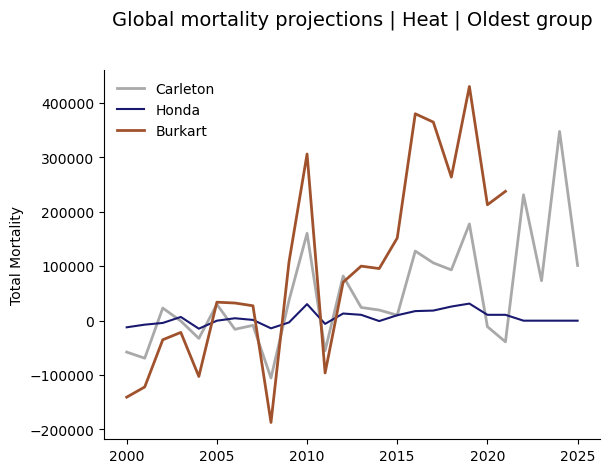

In [25]:
wdir = "X:\\user\\liprandicn\\mt-comparison\\"
temp_type = "Heat"
unit = "total"
age_group = "oldest"
region = "World"
diseases="All causes"

fig, ax = plt.subplots()

carleton = load_mortality(wdir+"carleton2022/output/DEFAULT/", "mortality_default_SSP2_ERA5_2000-2025", region, temp_type, unit, age_group, diseases)
honda = load_mortality(wdir+"honda2014/output/DEFAULT/", "mortality_default_SSP2_ERA5_IMAGE26_2000-2025_ot-2010", region, temp_type, unit, age_group, diseases)
burkart = load_mortality(wdir+"burkart2022/output/DEFAULT/", "mortality_default_SSP2_ERA5_countries_2000-2025", region, temp_type, unit, age_group, diseases)

plt.plot(carleton.columns, carleton.values.flatten(), label="Carleton", c="darkgrey", linewidth=2)
plt.plot(honda.columns, honda.values.flatten(), label="Honda", c="midnightblue")
plt.plot(burkart.columns[:-4], burkart.values.flatten()[:-4], label="Burkart", c="sienna", linewidth=2)

plt.title(f"Global mortality projections | {temp_type} | {age_group.capitalize()} group", y=1.1, fontsize=14)
plt.ylabel("Total Mortality")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(frameon=False)
plt.show()